In [10]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
#os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [11]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cpu


In [12]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load_Forecasts", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN_DAM_Forecasts", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load_Forecasts", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN_DAM_Forecasts", "FR_rt_ren_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test


In [4]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [13]:

#Normalization and splitting
train_df_FR, dev_df_FR, test_df_FR = split_data(all_data)


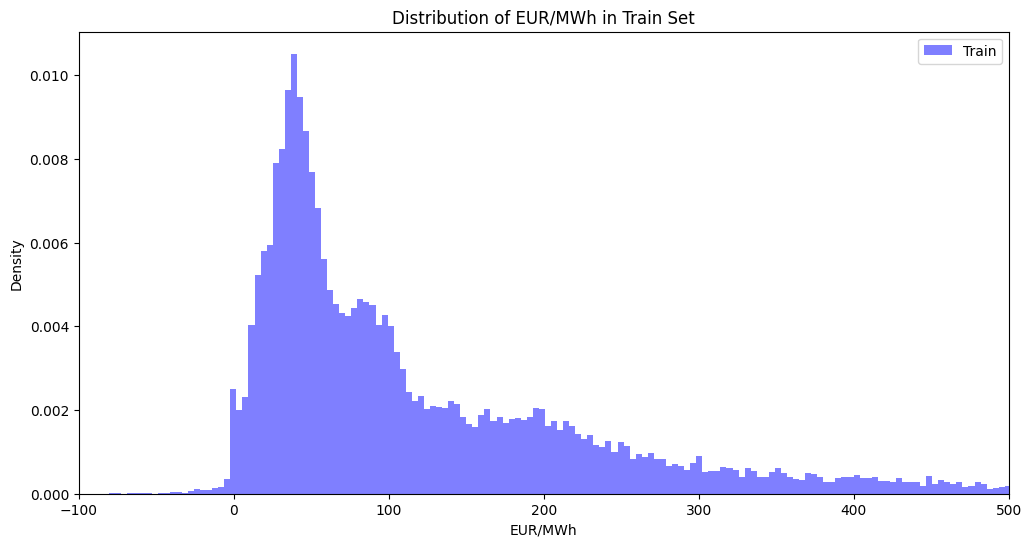

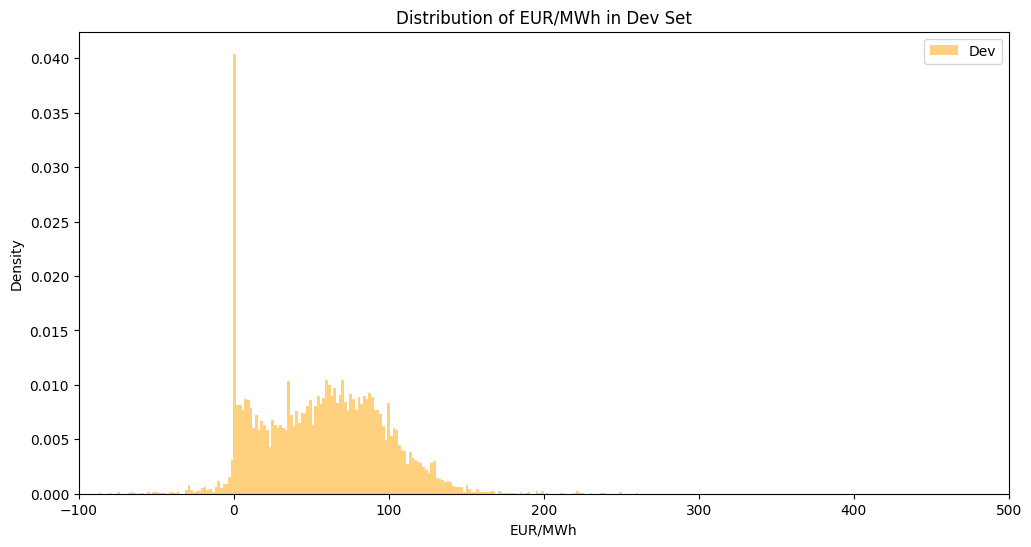

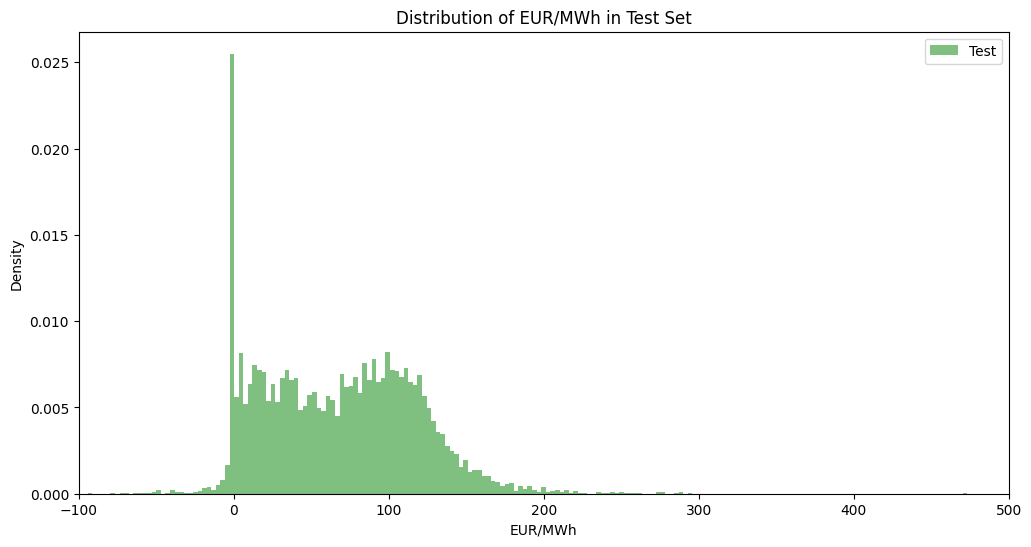

In [14]:
#Plot the distributions of train, dev, test sets on separate histograms
plt.figure(figsize=(12, 6))
plt.hist(train_df_FR['EUR/MWh'], bins=800, alpha=0.5, label='Train', color='blue', density=True)
plt.title('Distribution of EUR/MWh in Train Set')
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.xlim(-100, 500)
plt.legend()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(dev_df_FR['EUR/MWh'], bins=200, alpha=0.5, label='Dev', color='orange', density=True)
plt.title('Distribution of EUR/MWh in Dev Set')
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.xlim(-100, 500)
plt.legend()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(test_df_FR['EUR/MWh'], bins=200, alpha=0.5, label='Test', color='green', density=True)
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.title('Distribution of EUR/MWh in Test Set')
plt.xlim(-100, 500)
plt.legend()
plt.show()


In [ ]:


def normalize_dataset(train_df, dev_df, test_df):
    
    normalization_params = {}

    # --- 1. Target normalization (price) ---
    target = "EUR/MWh"
    mean_price = train_df[target].mean()
    std_price = train_df[target].std()
    normalization_params[target] = {"mean": mean_price, "std": std_price}

    for df in [train_df, dev_df, test_df]:
        df[target] = (df[target] - mean_price) / std_price

    # --- 2. Variables that exist in DA and RT versions ---
    paired_vars = ["Load", "Wind", "Solar"]

    for var in paired_vars:
        da_col = f"{var}_DA"
        rt_col = f"{var}_RT"

        # compute joint stats over DA + RT (train only)
        mean_val = pd.concat([train_df[da_col], train_df[rt_col]]).mean()
        std_val = pd.concat([train_df[da_col], train_df[rt_col]]).std()

        normalization_params[var] = {"mean": mean_val, "std": std_val}

        # apply normalization to all splits
        for df in [train_df, dev_df, test_df]:
            df[da_col] = (df[da_col] - mean_val) / std_val
            df[rt_col] = (df[rt_col] - mean_val) / std_val

    return train_df, dev_df, test_df, normalization_params


train_df_FR, dev_df_FR, test_df_FR, normalization_params_FR = normalize_dataset(train_df_FR, dev_df_FR, test_df_FR)


In [ ]:
train_df_FR

In [ ]:
#Create sliding windows

window_days = 7
forecast_horizon = 24
def create_aligned_windows(df,
                           past_feature_cols,
                           future_feature_cols,
                           target_col="EUR/MWh",
                           window_days=7,
                           forecast_horizon=24):
    # prepare
    hours = 24
    past_window = window_days * hours
    values = df.copy().reset_index(drop=True)
    vals = values.values
    cols = values.columns

    # index maps
    past_idx = [cols.get_loc(c) for c in past_feature_cols]
    fut_idx  = [cols.get_loc(c) for c in future_feature_cols]
    tgt_idx  = cols.get_loc(target_col)

    max_start = len(values) - past_window - forecast_horizon + 1   # +1 to include last valid start
    X_seq = []
    X_dnn = []
    starts = []   # store start timestamps for debugging/traceability

    for i in range(max_start):
        X_seq.append(vals[i : i + past_window, past_idx])                      # (168, k_past)
        X_dnn.append(vals[i + past_window : i + past_window + forecast_horizon, fut_idx])  # (24, k_future)
        starts.append(values.loc[i, 'Date'] if 'Date' in values.columns else i)

    return np.array(X_seq, dtype=np.float32), np.array(X_dnn, dtype=np.float32), starts


def create_targets(df, target_col="EUR/MWh", window_days=7, forecast_horizon=24):
    """
    Creates next-24-hour targets aligned with LSTM windows.
    """
    hours = 24
    window_size = window_days * hours
    series = df[target_col].values

    y = []
    y_day_before = []
    y_week_before = []

    for i in range(len(series) - window_size - forecast_horizon + 1):

                # Target: next `forecast_horizon` hours
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # --- Naive baselines ---
        # previous day
        if i - hours >= 0:
            y_prev_day = series[i + window_size - hours : i + window_size - hours + forecast_horizon]
        else:
            y_prev_day = np.full(forecast_horizon, np.nan)

        # previous week
        if i - 7 * hours >= 0:
            y_prev_week = series[i + window_size - 7 * hours : i + window_size - 7 * hours + forecast_horizon]
        else:
            y_prev_week = np.full(forecast_horizon, np.nan)

        
        y.append(y_target)
        y_day_before.append(y_prev_day)
        y_week_before.append(y_prev_week)

    return np.array(y, dtype=np.float32), np.array(y_day_before, dtype=np.float32), np.array(y_week_before, dtype=np.float32)



In [ ]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df


In [ ]:
#Add cyclical features to datasets
train_df_FR = add_cyclical_features(train_df_FR)
dev_df_FR = add_cyclical_features(dev_df_FR)
test_df_FR = add_cyclical_features(test_df_FR)
past_features = [
    'EUR/MWh',          # past prices
    'Load_RT',               # load
    'Wind_RT',     # wind
    'Solar_RT',            # solar
    'sin_hour', 'cos_hour',
    'sin_day',  'cos_day',
    'sin_month','cos_month'
]
future_features = [
    'Load_DA',               # load
    'Wind_DA',     # wind
    'Solar_DA',            # solar
    'sin_hour', 'cos_hour',
    'sin_day',  'cos_day',
    'sin_month','cos_month'
]
X_seq_train, X_dnn_train, starts_train = create_aligned_windows(
    train_df_FR,
    past_feature_cols=past_features,         # e.g. 10 past features
    future_feature_cols=future_features,         # e.g. ['Load_DA','Solar_DA','Wind_DA','sin_hour','cos_hour','sin_doy','cos_doy']
    target_col='EUR/MWh',
    window_days=7, forecast_horizon=24
)
X_seq_dev, X_dnn_dev, starts_dev = create_aligned_windows(
    dev_df_FR,
    past_feature_cols=past_features,         # e.g. 10 past features
    future_feature_cols=future_features,         #  e.g. ['Load_DA','Solar_DA','Wind_DA','sin_hour','cos_hour','sin_doy','cos_doy']
    target_col='EUR/MWh',
    window_days=7, forecast_horizon=24
)
X_seq_test, X_dnn_test, starts_test = create_aligned_windows(
    test_df_FR,
    past_feature_cols=past_features,         # e.g. 10 past features
    future_feature_cols=future_features,         # e.g. ['Load_DA','Solar_DA','Wind_DA','sin_hour','cos_hour','sin_doy','cos_doy']
    target_col='EUR/MWh',
    window_days=7, forecast_horizon=24
)
y_train,y_train_1d, y_train_7d = create_targets(train_df_FR)
y_dev, y_dev_1d, y_dev_7d = create_targets(dev_df_FR)
y_test, y_test_1d, y_test_7d = create_targets(test_df_FR)



In [ ]:
print("Shape of the LSTM inputs",X_seq_train.shape)
print("Shape of the DNN inputs",X_dnn_train.shape)
print("Shape of targets",y_train.shape)
print("Shape of 1-day before targets",y_train_1d.shape)
print("Shape of 7-day before targets",y_train_7d.shape)

In [ ]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [ ]:
def evaluate_model(
    model,
    X_seq_np, X_dnn_np,
    y_np, y_np_1d, y_np_7d,
    std_FR, mean_FR,
    shift=7*24,
    batch_size=128,
    device='cpu'
):
    """
    Evaluate a model that predicts 24-hour-ahead electricity prices
    using both LSTM sequential inputs (X_seq_np) and exogenous future
    features (X_dnn_np).

    y_np[i] contains the 24-hour target for day i.
    """

    model.to(device)
    model.eval()

    preds = []

    # ----------- Forward pass in batches ----------
    with torch.no_grad():
        for i in range(0, len(X_seq_np), batch_size):

            xb_seq = torch.from_numpy(X_seq_np[i:i+batch_size]).float().to(device)
            xb_dnn = torch.from_numpy(X_dnn_np[i:i+batch_size]).float().to(device)

            out = model(xb_seq, xb_dnn).cpu().numpy()

            preds.append(out)

    predictions = np.vstack(preds)

    # ----------- Denormalize -----------
    predictions = predictions * std_FR + mean_FR
    y_np       = y_np       * std_FR + mean_FR
    y_np_1d    = y_np_1d    * std_FR + mean_FR
    y_np_7d    = y_np_7d    * std_FR + mean_FR

    # ----------- Standard MAE -----------
    mae_model_full = np.mean(np.abs(predictions - y_np))

    median_val = np.median(y_np)
    mae_median = np.mean(np.abs(median_val - y_np))
    maem = mae_model_full / mae_median

    # ----------- rMAE with 1-day naive baseline -----------
    # (Using previous day’s actuals)
    preds_trim_1d = predictions[24:]
    true_1d       = y_np[24:]
    naive_1d      = y_np_1d[24:]

    mae_naive_1d = np.mean(np.abs(naive_1d - true_1d))
    mae_model_1d = np.mean(np.abs(preds_trim_1d - true_1d))
    rMAE_1d = mae_model_1d / mae_naive_1d

    # ----------- rMAE with 7-day naive baseline -----------
    if len(y_np) <= shift:
        raise ValueError(f"Need more than {shift} samples to compute 7-day baseline.")

    preds_trim_7d = predictions[shift:]
    true_7d       = y_np[shift:]
    naive_7d      = y_np_7d[shift:]

    mae_naive_7d = np.mean(np.abs(naive_7d - true_7d))
    mae_model_7d = np.mean(np.abs(preds_trim_7d - true_7d))
    rMAE_7d = mae_model_7d / mae_naive_7d

    # ----------- Print results -----------
    print(f"MAE: {mae_model_full:.6f} "
          f"| MAEm: {maem:.6f} "
          f"| rMAE (1 day): {rMAE_1d:.6f} "
          f"| rMAE (7 days): {rMAE_7d:.6f}")

    return {
        "predictions": predictions,
        "MAE": mae_model_full,
        "MAEm": maem,
        "rMAE (1 day)": rMAE_1d,
        "rMAE (7 days)": rMAE_7d,
    }


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class RNN(nn.Module):
    def __init__(
        self,
        n_features,
        seq_len,
        output_dim,
        hidden_size=128,
        num_layers=2,
        dropout=0.2,
        use_batchnorm=True,
        leaky_alpha=0.1,
        future_dim=None,            # set after model creation
        future_horizon=None         # set after model creation
    ):
        super().__init__()

        self.seq_len = seq_len
        self.n_features = n_features
        self.output_dim = output_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_batchnorm = use_batchnorm
        self.leaky_alpha = leaky_alpha

        # ---- LSTM BRANCH ----
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        # ---- FUTURE DNN BRANCH ----
        # future_dim and future_horizon get set *after* model creation
        self.future_dim = future_dim
        self.future_horizon = future_horizon

        # Will initialize once we know the future size
        self.future_dense = None

        # ---- FINAL MLP ----
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_dim)

        if use_batchnorm:
            self.bn_lstm = nn.BatchNorm1d(hidden_size)
            self.bn_fc1 = nn.BatchNorm1d(hidden_size)

        self.dropout = nn.Dropout(dropout)


    def build_future_module(self):
        """Builds the DNN for future features after shape is known."""
        if self.future_dim is None or self.future_horizon is None:
            return

        fut_input_size = self.future_dim * self.future_horizon

        self.future_dense = nn.Sequential(
            nn.Linear(fut_input_size, self.hidden_size),
            nn.LeakyReLU(self.leaky_alpha),
            nn.Dropout(0.2),

            nn.Linear(self.hidden_size, self.hidden_size),
            nn.LeakyReLU(self.leaky_alpha)
        )


    def forward(self, seq_x, future_x=None):
        """
        seq_x:     (B, seq_len, n_features)
        future_x:  (B, horizon, k_future)
        """

        # Build the future branch if needed
        if self.future_dense is None and future_x is not None:
            self.future_dim = future_x.shape[-1]
            self.future_horizon = future_x.shape[1]
            self.build_future_module()

        # ----- LSTM BRANCH -----
        lstm_out, (h, c) = self.lstm(seq_x)
        h = h[-1]  # last layer hidden state (B, hidden_size)

        if self.use_batchnorm:
            h = self.bn_lstm(h)

        h = F.leaky_relu(h, negative_slope=self.leaky_alpha)
        h = self.dropout(h)

        # ----- FUTURE FEATURES BRANCH -----
        if future_x is not None:
            B = future_x.shape[0]
            fut = future_x.reshape(B, -1)  # flatten horizon and features
            fut = self.future_dense(fut)

            x = h + fut   # can also concatenate, but sum works well
        else:
            x = h

        # ----- FINAL PREDICTION -----
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn_fc1(x)
        x = F.leaky_relu(x, negative_slope=self.leaky_alpha)
        x = self.dropout(x)

        out = self.fc2(x)  # (B, output_dim)
        return out


In [ ]:
def run_full_train(
        X_seq_train_np, X_dnn_train_np, y_train_np,
        X_seq_dev_np,   X_dnn_dev_np,   y_dev_np,
        dropout,
        use_batchnorm,
        leaky_alpha,
        learning_rate,
        weight_decay,
        l1_lambda,
        batch_size,
        epochs,
        verbose_freq = 1
    ):

    features   = X_seq_train_np.shape[2]
    seq_len    = X_seq_train_np.shape[1]
    output_dim = y_train_np.shape[1]

    # -------- MODEL ---------
    MODEL = RNN(
        n_features  = features,
        seq_len     = seq_len,
        output_dim  = output_dim,
        dropout     = dropout,
        use_batchnorm = use_batchnorm,
        leaky_alpha = leaky_alpha
    ).to(device)

    optimizer = torch.optim.Adam(
        MODEL.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=3, min_lr=1e-6
    )

    print("Model:")
    print(MODEL)
    print("Optimizer:", optimizer)
    print("Batch size:", batch_size, "Epochs:", epochs)

    train_hist = []
    val_hist   = []

    # convert only once
    X_seq_dev_t = torch.from_numpy(X_seq_dev_np).float().to(device)
    X_dnn_dev_t = torch.from_numpy(X_dnn_dev_np).float().to(device)
    y_dev_t     = torch.from_numpy(y_dev_np).float().to(device)

    # loss
    mae = nn.L1Loss()

    for epoch in range(epochs):

        # -------- SHUFFLE ---------
        perm = np.random.permutation(len(X_seq_train_np))
        X_seq_shuf = X_seq_train_np[perm]
        X_dnn_shuf = X_dnn_train_np[perm]
        y_shuf     = y_train_np[perm]

        MODEL.train()
        epoch_train_loss = 0.0
        n_seen = 0

        for i in range(0, len(X_seq_shuf), batch_size):

            xb_seq = torch.from_numpy(X_seq_shuf[i:i+batch_size]).float().to(device)
            xb_dnn = torch.from_numpy(X_dnn_shuf[i:i+batch_size]).float().to(device)
            yb     = torch.from_numpy(y_shuf[i:i+batch_size]).float().to(device)

            optimizer.zero_grad()

            pred = MODEL(xb_seq, xb_dnn)

            loss = mae(pred, yb)

            # ---- L1 regularization ----
            if l1_lambda and l1_lambda > 0:
                l1 = sum(torch.sum(torch.abs(p)) for p in MODEL.parameters())
                loss = loss + l1_lambda * l1

            loss.backward()
            optimizer.step()

            bs = xb_seq.size(0)
            epoch_train_loss += loss.item() * bs
            n_seen += bs

        epoch_train_loss /= n_seen
        train_hist.append(epoch_train_loss)

        # -------- VALIDATION ---------
        MODEL.eval()
        with torch.no_grad():
            pred_dev = MODEL(X_seq_dev_t, X_dnn_dev_t)
            val_loss = mae(pred_dev, y_dev_t).item()

        val_hist.append(val_loss)
        scheduler.step(val_loss)

        if verbose_freq and epoch % verbose_freq == 0:
            print(f"Epoch {epoch+1}/{epochs} | train={epoch_train_loss:.6f} | val={val_loss:.6f}")

    return MODEL, train_hist, val_hist


In [ ]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [ ]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": { 
        "dropout": 0.12027703056899208,
        "use_batchnorm": False,
        "leaky_alpha": 0.06476370399933795,
        "learning_rate": 0.0007062721927991056,
        "weight_decay": 2.3704198924044438e-05,
        "l1_lambda": 3.4985631147347504e-05,
        "batch_size": 128,
        "epochs": 10,
     },
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_seq_train, X_dnn_train, y_train, X_seq_dev, X_dnn_dev, y_dev,
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_seq_dev, X_dnn_dev, y_dev, y_dev_1d, y_dev_7d, std_FR=normalization_params_FR["std"], mean_FR=normalization_params_FR["mean"], device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

In [ ]:
std=normalization_params_FR["std"]
mean=normalization_params_FR["mean"]

In [ ]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, X_seq_test, X_dnn_test, y_test, y_test_1d, y_test_7d, std_FR=std, mean_FR=mean, device=device)


In [ ]:
print("Evaluating on training set:")
eval_res_train = evaluate_model(model, X_seq_train, X_dnn_train, y_train, y_train_1d, y_train_7d, std_FR=std, mean_FR=mean, device=device)
#Plot the first 24 hours of the training set
idx=np.random.randint(168, len(y_train)-1)
plt.figure(figsize=(12,6))
plt.plot(eval_res_train['predictions'][idx], label='Model Predictions')
plt.plot(y_train[idx]*std + mean, label='True Prices')
plt.plot(y_train_1d[idx]*std + mean, label='True Values Previous Day', linestyle='--')
plt.plot(y_train_7d[idx]*std + mean, label='True Values Previous Week', linestyle=':')
plt.title('Model Predictions vs True Prices (Training Set)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()  

In [ ]:
#Plot on the forst 24 hours of the test set
idx=np.random.randint(168, len(y_test)-1)

plt.figure(figsize=(10, 5))
plt.plot(eval_res_test['predictions'][idx], label='Model Predictions')
plt.plot(y_test[idx]*std + mean, label='True Values')
plt.plot(y_test_1d[idx]*std + mean, label='True Values Previous Day', linestyle='--')
plt.plot(y_test_7d[idx]*std + mean, label='True Values Previous Week', linestyle=':')
plt.title('Test Set Predictions (First 24 Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()

In [ ]:
#Hyperparameter search
dropout = np.linspace(0.0, 0.5, 5)
lr = np.logspace(-5, -3, 5)
results = {}

for d in dropout:
    for learning_rate in lr:
        print(f"Training with dropout {d} and learning rate {learning_rate}")
        model, train_hist, val_hist = run_full_train(
            X_train, y_train_FR, X_dev, y_dev_FR,
            dropout = d,
            use_batchnorm = False,
            leaky_alpha = 0.0,
            learning_rate = learning_rate,
            weight_decay = 0.0,
            l1_lambda = 0.0,
            batch_size = 128,
            train_amt = len(X_train_FR),
            epochs = 20,
            verbose_freq = 10
        )

        print("Evaluating on dev set:")
        eval_res = evaluate_model(
            model, X_dev, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, 
            std_FR, mean_FR, device=device
        )
        print("\n")

        # store clean results
        results[(d, learning_rate)] = {
            "MAE": eval_res["MAE"],
            "MAEm": eval_res["MAEm"],
            "rMAE1": eval_res["rMAE (1 day)"],
            "rMAE7": eval_res["rMAE (7 days)"],
        }

# --- find best ---
min_mae = min(v["MAE"] for v in results.values())
min_maem = min(v["MAEm"] for v in results.values())
min_rmae1 = min(v["rMAE1"] for v in results.values())
min_rmae7 = min(v["rMAE7"] for v in results.values())

best_configs_mae = [k for k,v in results.items() if v["MAE"] == min_mae]
best_configs_maem = [k for k,v in results.items() if v["MAEm"] == min_maem]
best_configs_rmae1 = [k for k,v in results.items() if v["rMAE1"] == min_rmae1]
best_configs_rmae7 = [k for k,v in results.items() if v["rMAE7"] == min_rmae7]

print(f"Best configurations for minimum MAE ({min_mae}): {best_configs_mae}")
print(f"Best configurations for minimum MAEm ({min_maem}): {best_configs_maem}")
print(f"Best configurations for minimum rMAE (1 day) ({min_rmae1}): {best_configs_rmae1}")
print(f"Best configurations for minimum rMAE (7 days) ({min_rmae7}): {best_configs_rmae7}")

In [ ]:
results


In [ ]:
# ...existing code...
# This cell: build short labels, fill matrices, find minima and plot grid with metric-text colored per-minimum
# collect unique architectures and lrs (same ordering as rMAE plot)
archs = sorted({k[0] for k in results.keys()})   # dropout values
lrs   = sorted({k[1] for k in results.keys()})   # learning rates


# metrics to show in each grid cell
metric_keys = ["MAE", "MAEm", "rMAE1", "rMAE7"]


# prepare matrices for each metric and multiline text for annotations
metrics_mats = {mk: np.full((len(archs), len(lrs)), np.nan, dtype=float) for mk in metric_keys}
cell_text = np.full((len(archs), len(lrs)), "", dtype=object)

for (arch, lr) in results.keys():
    v = results[(arch, lr)]
    if isinstance(v, dict) and "eval" in v and isinstance(v["eval"], dict):
        ev = v["eval"]
    elif isinstance(v, dict) and any(k in v for k in metric_keys):
        ev = v
    else:
        ev = None

    i = archs.index(arch)   # arch is already a float
    j = lrs.index(lr)       # lr is also a float

    if ev is None:
        cell_text[i, j] = "no eval"
        continue

    # use short, unambiguous labels so rMAE (1 day) / (7 days) are distinct in the cell text
    short_labels = {
        "MAE": "MAE",
        "MAEm": "MAEm",
        "rMAE1": "rMAE1",
        "rMAE7": "rMAE7",
    }

    parts = []
    for mk in metric_keys:
        val = ev.get(mk, np.nan)
        try:
            valf = float(val)
        except Exception:
            valf = np.nan
        metrics_mats[mk][i, j] = valf
        lab = short_labels.get(mk, mk.split()[0])
        parts.append(f"{lab}:{valf:.3f}" if not np.isnan(valf) else f"{lab}:nan")
    cell_text[i, j] = "\n".join(parts)

# --- find minimum positions for each metric (ignore NaNs) ---
min_positions = {}
for mk in metric_keys:
    mat = metrics_mats[mk]
    if np.all(np.isnan(mat)):
        min_positions[mk] = []
    else:
        min_val = np.nanmin(mat)
        # positions as (row, col) tuples
        pos = list(zip(*np.where(np.isclose(mat, min_val, atol=1e-12))))
        min_positions[mk] = pos

# --- Plot grid WITHOUT heatmap, annotate every cell with 4 metrics and highlight minima ---
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(16, 8 + 0.6 * len(archs)))
ax.set_xlim(-0.5, len(lrs) - 0.5)
ax.set_ylim(len(archs) - 0.5, -0.5)  # origin at top to match previous layout
# set_xticks / set_yticks do not accept fontsize; set font size via set_xticklabels / set_yticklabels
ax.set_xticks(range(len(lrs)))
ax.set_xticklabels([f"{lr:.0e}" for lr in lrs], fontsize=16, rotation=45)
ax.set_yticks(range(len(archs)))
ax.set_yticklabels([str(a) for a in archs], fontsize=16)
ax.set_xlabel("learning rate", fontsize=16)
ax.set_ylabel("dropout", fontsize=16)

# draw light grid lines
for x in range(len(lrs) + 1):
    ax.axvline(x - 0.5, color='lightgray', linewidth=0.8)
for y in range(len(archs) + 1):
    ax.axhline(y - 0.5, color='lightgray', linewidth=0.8)

# colors for each metric's minima (kept distinct)
colors = ['red', 'blue', 'green', 'purple']
metric_colors = {mk: colors[idx % len(colors)] for idx, mk in enumerate(metric_keys)}
legend_patches = [patches.Patch(color=metric_colors[mk], label=mk) for mk in metric_keys]

# annotate every cell with the 4 metrics as separate text items, color the line if it's a metric minimum
# vertical offsets inside a cell (from top to bottom rows use negative->positive relative to center)
y_offsets = [-0.35, -0.12, 0.12, 0.35]

for i in range(len(archs)):
    for j in range(len(lrs)):
        ev_lines = cell_text[i, j].split("\n") if (cell_text[i, j] and isinstance(cell_text[i, j], str)) else []
        if not ev_lines:
            ax.text(j, i, "no eval", ha='center', va='center', fontsize=7, color='gray')
            continue

        # for each metric place a separate text entry with its own color (default black)
        for k, mk in enumerate(metric_keys):
            line = ev_lines[k] if k < len(ev_lines) else ""
            if not line:
                continue
            # default color
            txt_color = 'black'
            # if this (i,j) is one of the minima positions for this metric, color the metric text
            if (i, j) in min_positions.get(mk, []):
                txt_color = metric_colors[mk]
            ax.text(j, i + y_offsets[k], line, ha='center', va='center', fontsize=16, color=txt_color)

# place legend outside plot to the right
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, borderaxespad=0.1)

plt.tight_layout()
plt.savefig("metrics_grid_minima_text_colored.png", bbox_inches='tight')
plt.show()
# ...existing code...

In [ ]:
def objective(trial):
    # --- Hyperparameters to tune ---
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs = 20  # you can reduce for faster search

    # --- Train model ---
    MODEL, train_hist, val_hist = run_full_train(
        X_train_np=X_train, y_train_np=y_train_FR,
        X_dev_np=X_dev, y_dev_np=y_dev_FR,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        train_amt=len(X_train),
        epochs=epochs,
        verbose_freq=None
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(MODEL, X_dev, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, std_FR, mean_FR)
    mae=metrics["MAE"]
    maem=metrics["MAEm"]
    rmae_1d=metrics["rMAE (1 day)"]  # smaller = better
    rmae_7d=metrics["rMAE (7 days)"]  # smaller = better

    return mae,maem, rmae_1d, rmae_7d
# --- Run the study ---
study = optuna.create_study(directions=["minimize","minimize","minimize","minimize"])    
study_name="FR_LMP_MLP"
study.optimize(objective, n_trials=20, timeout=None)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.")

for t in best_trials:
    print(f"Values: {t.values}")
    print(f"Params: {t.params}")

